# The LLAMA of WallStreet: LLM data extraction and sentiment analysis 

**Read carefully the following instructions and suggestions before writing code.**

## Task description and suggestions

You work as Data Scientist in a company that develops algorithmic trading strategies. 
Your supervisor aims to develop a sentiment analysis pipeline for Reddit posts, with the objective of incorporating Reddit comments into an automated trading strategy.  
The goal is to leverage the content of these comments to extract actionable insights for identifying potential stock buying or selling opportunities. 

In particular, he wants a dataset with the `ticker` (or stock symbol: AAPL for Apple, TSLA for Tesla etc...) of the company and the general `sentiment`  towards that stock.

Moreover, he wants to be able to analyze comments every day using Leonardo and `SLURM`, **BUT**, unfortunately, he does not know how to write or execute code.
He only wants to send prompt in natural english.


The pipeline you are going to create does not have any particular constraint about the technologies to be used; however, here are **some important suggestions**:

1. The **number of comments to be processed is big**, we are talking about 100k comments. So, it is **strongly advised to parallelize your workflow in some way** (i.e. multitrheading or other options)... the choice is yours.

2. Alternatevely, you can analyze just a smaller subset of the dataframe, again, the choice is yours.

3. The data extraction task (i.e. verifying a comment is about companies and identifying a ticker associated to the comment) can be done leveraging "LLM knowledge". In the section "Data extraction example" you can find an example of how to use an LLM for data extraction.

4. Once you have identified the relevant comments and associated them with their respective stock tickers, the sentiment analysis task can be carried out using either a large language model (LLM) or a domain-specific pre-trained model (e.g. [cardiffnlp/twitter-roberta-base-sentiment-latest](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)) or any other sentiment analysis model. 
The choice is yours; however, keep in mind that if you plan to run the sentiment analysis on worker nodes, the model must be downloaded and made available on those nodes in advance.

5. Write down, in a Markdown cell, the architecture/plan/structure/technology you would use to convert this workflow into an agentic system that can send the `student_job_LLM.py` SLURM script to the Leonardo cluster and run the analysis above. Imagine that this would become a tool for data scientists in an organization: they would interact with chatbots, but sometimes ask for this analysis to be run on Leonardo and then receive the results. The idea is to reason about how this could become chatbot functionality implemented as an agent plus a certain number of tools. **HINT**: remember the example shown during Lesson 7 [`1_agent_applications_the_slurmjob_maker.ipynb`](../../lecture_8/notebooks/1_agent_applications_the_slurmjob_maker.ipynb).

6. Given the layout you described in point 5, the tools you defined, and the responsibilities of the agentic system, write the system prompt for this system.

7. **OPTIONAL**: actually write the agentic system. Implement it in this notebook, using the LLM we provide, and show that it prepares SLURM jobs that would launch `student_job_LLM.py` on Leonardo, get job status, and optionally fetch the results locally. **HINT**: remember the example shown during Lesson 7 [`1_agent_applications_the_slurmjob_maker.ipynb`](../../lecture_8/notebooks/1_agent_applications_the_slurmjob_maker.ipynb).


**Given the large number of comments, it may be helpful to use this notebook as a playground to test the pipeline on a small subset first. Once you've implemented and verified your logic here, you can move it to a .py script and run it as a non-interactive job. For a template, see the `student_job_LLM.py` and `config/LLM_start_job.job` scripts. That said, feel free to organize your code in whatever way works best for you.**

Note that in this notebook we limited the number of comments to be processed to 1000. Change the variable LIMIT if you want to make tests with more comments in this notebook.  

# Data extraction example

LLMs can be effectively used to solve data extraction tasks. For instance, consider a collection of legal documents where laws are cited in inconsistent formats. You can provide an LLM with a system prompt that includes examples of how laws are typically cited and instruct it to extract all legal citations from the text using a standardized response format. This approach enables the model to recognize and structure heterogeneous references in a consistent way.

Response format is specified as a Python class which extends a pydantic BaseModel class. This is all you need to know, don't worry you don't need to study pydantic...  
Below you can find an example.  

In [28]:
# Using structured outputes to constraint the answer to have a specific format

SYSTEM_PROMPT = """You are an helpful assistant trained to extract Laws citations from legal proceedings.
You will be given a sentence, your task is to extract citations using the following format: [{"article": "<article_no>", "code":"<law_collection>"}].

- <article_no> is a string containing the number of the cited article
- <law_collection> is the name of the code containing the cited law. Law collection can assume only 3 possible values: United States Code, Code of Federal Regulations, NA if the name of the document is not present or the input text does not contain any citation.

Here are some examples:

[INPUT]: Tomorrow I have an exam about USC art. 1
[OUTPUT]: [{"article": "1", "code": "United States Code"}]
[INPUT]: I like pizza!
[OUTPUT]: [{"article":"NA", "code": "NA"}]
[INPUT]: I found article 22 of the United States Code very clear. On the opposite, the art 13 of CFR is totally incomprensible.
[OUTPUT]: [{"article": "22", "code": "United States Code"}, {"article": "13", "code": "Code of Federal Regulations"}]
"""


class Codes(Enum):
    USC = "United States Code"
    CFR = "Code of Federal Regulations"
    NA = "NA"


class Citation(BaseModel):
    article: str
    code: Codes


class Citations(BaseModel):
    citations: list[Citation]


answ = llm.with_structured_output(Citations).invoke(
    input=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": "Did you study article 33 of the USC and article 3475-bis of USC?",
        },
    ],
    temperature=0,
)

answ

Citations(citations=[Citation(article='33', code=<Codes.USC: 'United States Code'>), Citation(article='3475-bis', code=<Codes.USC: 'United States Code'>)])

Then you can acces values by iterating over the elements of the list. The output of the llm invocation is a standard python object!

**If you get a connection error running the above cell, it's because the model is still being loaded. In this case you must wait a bit and try again...**

In [29]:
for citation in answ.citations:
    print(f"Article: {citation.article}\nCode: {citation.code.value}\n\n")

Article: 33
Code: United States Code


Article: 3475-bis
Code: United States Code




# Logical steps to follow

1. Extract one or more tickers from each comment. 

2. Associate a sentiment (very positive, positive, neutral, negative, very negative) to each comment. To perform this task you can use an LLM or a model trained specifically for this task;

3. Map sentiment to integers: 2, 1, 0, -1, -2; 

4. Once you have mapped sentiment to numbers, calculate a daily sentiment for each ticker; 

5. Calculate some metrics (e.g. min, max, average sentiment) for each ticker on a daily basis; 

6. Plot the sentiment trend for some tickers you find interesting (e.g. AAPL, META, etc.) 

# Imports

In [26]:
from datetime import datetime

from pydantic import BaseModel
from enum import Enum

from langchain_openai import ChatOpenAI

import pandas as pd
import seaborn as sns

# General config

The following general configuration dir sets the LLM that you may use in your project.  

In [2]:
t0 = datetime.now()
print(f"Execution started: {t0}")

INPUT_FILE = "reddit_comments.csv"
MODEL_NAME = "mistralai/Mistral-Small-3.2-24B-Instruct-2506"

VLLM_ENDPOINT = "http://127.0.0.1:8000/v1"
API_KEY = "password"

# OpenAI client pointing to our local model
llm = ChatOpenAI(base_url=VLLM_ENDPOINT, api_key=API_KEY, model=MODEL_NAME)

Execution started: 2026-06-21 22:10:07.543830


In [3]:
llm.invoke("Hello, world!")

AIMessage(content='Hello! 😊 How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 7, 'total_tokens': 20, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'mistralai/Mistral-Small-3.2-24B-Instruct-2506', 'system_fingerprint': None, 'id': 'chatcmpl-b05223a2323cd758', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eebce-13a9-7b61-8101-2a96ccc1742a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token_details': {}, 'output_token_details': {}})

# Read data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("reddit_comments.csv")
print(df.info())
LIMIT = 101974
df_sample = df.sample(LIMIT, random_state=42).reset_index(drop=True)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 101974 entries, 0 to 101973
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   datetime       101974 non-null  str  
 1   subreddits     101974 non-null  str  
 2   submission_id  101974 non-null  str  
 3   comments       101974 non-null  str  
dtypes: str(4)
memory usage: 3.1 MB
None


,datetime,subreddits,submission_id,comments
0,2025-03-29 18:32:13,news,1jmrj8p,A British man has been praised for tackling a ...
1,2025-03-29 18:32:13,news,1jmrj8p,Glad they recognized him. He did a great thing.
2,2025-03-29 18:32:13,news,1jmrj8p,A news on a British tourist that doesn't invol...
3,2025-03-29 18:32:13,news,1jmrj8p,That guys needs some real love. Hopefully he A...
4,2025-03-29 18:32:13,news,1jmrj8p,"“I’m Millwall, mate”. Probably"


# Extract tickers and sentiment analysis

In [10]:
class SentimentEnum(str, Enum):
    very_positive = "very positive"
    positive = "positive"
    neutral = "neutral"
    negative = "negative"
    very_negative = "very negative"

class StockComment(BaseModel):
    tickers: list[str]         
    sentiment: SentimentEnum

SYSTEM_PROMPT_STOCK = """You are a financial analyst assistant.
Given a Reddit comment, extract:
1. The stock ticker symbol(s) of the companie(s) being discussed (e.g. AAL for American airlines or AA, AAPL for Apple, TSLA for Tesla).
   - If the comment does not mention any publicly traded company, return ["NA"].
   - If multiple companies are mentioned, return all of them in the list.
2. The overall sentiment. You MUST strictly use these criteria:
   - "very positive": Euphoric comments, urging to buy, e.g. "To the moon!"
   - "positive": Bullish but calm sentiment.
   - "neutral": Just sharing news or asking questions.
   - "negative": Bearish but calm sentiment.
   - "very negative": Extreme panic, urging to sell, e.g. "going to 0", "bankruptcy".

Respond strictly in the requested JSON format. No explanations."""

structured_llm = llm.with_structured_output(StockComment)

def analyze_comment(comment: str) -> dict:
    try:
        result = structured_llm.invoke([
            {"role": "system", "content": SYSTEM_PROMPT_STOCK},
            {"role": "user", "content": comment}
        ])
        return {"tickers": result.tickers, "sentiment": result.sentiment}
    except Exception as e:
        return {"tickers": ["NA"], "sentiment": "neutral"}

# Parallelization using ThreadPoolExecutor with 32 workers 
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

results = [None] * len(df_sample)

with ThreadPoolExecutor(max_workers=32)as executor:
    futures = {executor.submit(analyze_comment, row["comments"]): i 
               for i, row in df_sample.iterrows()}
    for future in tqdm(as_completed(futures), total=len(futures)):
        idx = futures[future]
        results[idx] = future.result()


100%|██████████| 101974/101974 [23:50<00:00, 71.27it/s]


In [11]:

df_sample["tickers"]    = [r["tickers"]    for r in results]
df_sample["sentiment"] = [r["sentiment"] for r in results]

# Explode the dataframe so each ticker gets its own row, then rename to maintain compatibility
df_sample = df_sample.explode("tickers").rename(columns={"tickers": "ticker"})

print(df_sample[["comments", "ticker", "sentiment"]].head(10))

                                            comments ticker  \
0                     Truly a hero we do not deserve     NA   
1  Honestly, this whole case was absurd once it c...     NA   
2  I don’t understand why a single judge in Misso...     NA   
3                     Great, do the rest of them now     NA   
4  They'll quietly come back within a few months,...     NA   
5  Nazi presence and tourist friendly do not belo...     NA   
6  Republicans just making life miserable for peo...     NA   
7  > On June 18, 2021, Aldrich's maternal grandpa...     NA   
8  Good. It's about time there is some accountabi...     NA   
9              *I thought hurricane season was ova!*     NA   

                sentiment  
0   SentimentEnum.neutral  
1   SentimentEnum.neutral  
2  SentimentEnum.negative  
3   SentimentEnum.neutral  
4  SentimentEnum.positive  
5   SentimentEnum.neutral  
6  SentimentEnum.negative  
7   SentimentEnum.neutral  
8   SentimentEnum.neutral  
9   SentimentEnum.neutral 

In [12]:
df_sample.to_csv("sentiment_analysis.csv")

In [13]:
df_sample= pd.read_csv("sentiment_analysis.csv")

In [14]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 103989 entries, 0 to 103988
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     103989 non-null  int64
 1   datetime       103989 non-null  str  
 2   subreddits     103989 non-null  str  
 3   submission_id  103989 non-null  str  
 4   comments       103989 non-null  str  
 5   ticker         6969 non-null    str  
 6   sentiment      103989 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.6 MB


In [15]:
# Filter only comments where a ticker was found
df_with_ticker = df_sample[~df_sample["ticker"].isna()]

print(f"Comments with ticker: {len(df_with_ticker)} out of {len(df_sample)}")
print(df_with_ticker[["comments", "ticker", "sentiment"]].head())

Comments with ticker: 6969 out of 103989
                                             comments ticker      sentiment
11  Clear evidence of Russian propaganda campaigns...   TSLA  very negative
13  UHC just two mf days ago forced me to see a sp...    UHC  very negative
43  Major defense contractors like Boeing have ric...     BA       negative
81  At least Delta only breaks guitars, American A...    DAL  very negative
82  At least Delta only breaks guitars, American A...    AAL  very negative


In [16]:
sentiment_map = {
    "very positive":  2,
    "positive":       1,
    "neutral":        0,
    "negative":      -1,
    "very negative": -2
}

df_sample["sentiment_score"] = df_sample["sentiment"].map(sentiment_map)
df_sample

extreme = df_sample[df_sample["sentiment_score"].isin([2, -2])]
print(f"Very positive: {len(extreme[extreme['sentiment_score'] == 2])}")
print(f"Very negative: {len(extreme[extreme['sentiment_score'] == -2])}")
extreme[["comments", "ticker", "sentiment", "sentiment_score"]]

Very positive: 309
Very negative: 9837


,comments,ticker,sentiment,sentiment_score
11,Clear evidence of Russian propaganda campaigns...,TSLA,very negative,-2
13,UHC just two mf days ago forced me to see a sp...,UHC,very negative,-2
20,Damn you! God damn you all to hell!,NaN,very negative,-2
21,What kind of fucking imbecile would do this to...,NaN,very negative,-2
61,"Own version of ""Scared Straight"". This guy jus...",NaN,very negative,-2
...,...,...,...,...
103932,This situation is *so* fucked. Who would want ...,NaN,very negative,-2
103944,As an NC resident…Fuck you mark,NaN,very negative,-2
103972,And to think it all just turns into shit,NaN,very negative,-2
103977,I am absolutely disgusted. What was all that f...,NaN,very negative,-2


# Metrics

In [17]:
df_stocks = df_sample[df_sample["ticker"] != "NA"].copy()
df_stocks["date"] = pd.to_datetime(df_stocks["datetime"]).dt.date

daily = (
    df_stocks
    .groupby(["ticker", "date"])["sentiment_score"]
    .agg(mean="mean", min="min", max="max", count="count")
    .reset_index()
)

print(daily.sort_values(["ticker", "date"]).head(20))

   ticker        date      mean  min  max  count
0       A  2024-04-02  0.000000    0    0      1
1      AA  2024-04-02 -2.000000   -2   -2      1
2      AA  2024-04-08  0.000000    0    0      1
3      AA  2024-04-22  0.000000    0    0      1
4      AA  2024-04-24 -1.250000   -2   -1      4
5      AA  2024-05-13 -1.000000   -1   -1      2
6      AA  2024-05-22 -1.076923   -2    1     26
7      AA  2024-05-24 -1.111111   -2    0     18
8      AA  2024-10-29 -0.600000   -1    1      5
9      AA  2024-11-04 -2.000000   -2   -2      1
10     AA  2024-11-18 -2.000000   -2   -2      3
11     AA  2024-12-24 -0.111111   -1    0      9
12     AA  2024-12-28  0.000000    0    0      1
13     AA  2025-01-07  0.000000    0    0      1
14     AA  2025-01-22 -1.000000   -1   -1      1
15     AA  2025-01-25  0.000000    0    0      2
16    AAA  2024-04-24 -2.000000   -2   -2      2
17    AAL  2024-03-12  0.000000    0    0      1
18    AAL  2024-03-25 -1.000000   -1   -1      1
19    AAL  2024-04-0

# Trend

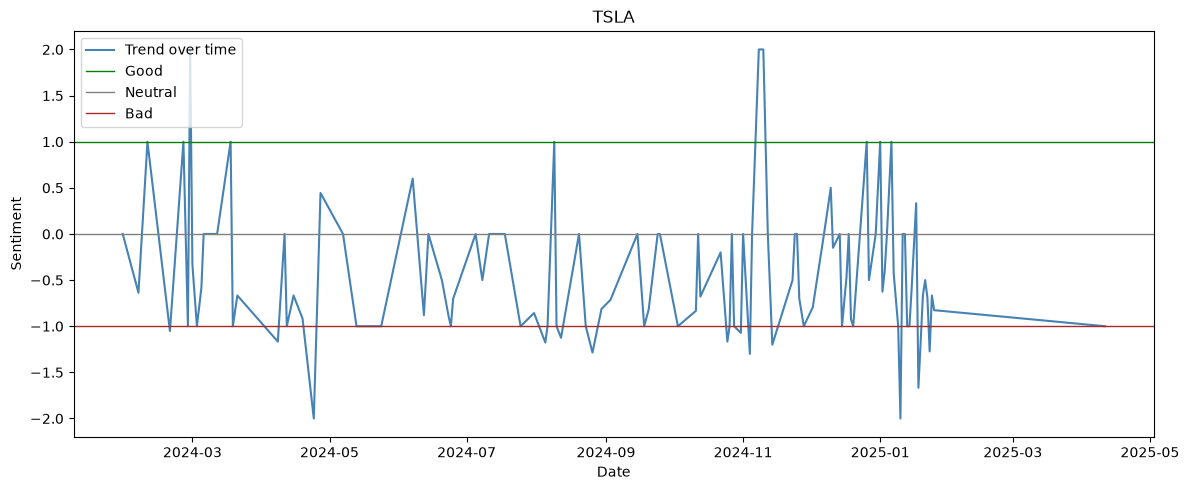

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
top_tickers = df_stocks["ticker"].value_counts().head(1).index.tolist()

for ticker in top_tickers:
    data = daily[daily["ticker"] == ticker].sort_values("date")
    ax.plot(data["date"], data["mean"], label="Trend over time", color="steelblue", linewidth=1.5)

ax.axhline(1, color="green", linewidth=1, label="Good")
ax.axhline(0, color="gray", linewidth=1, label="Neutral")
ax.axhline(-1, color="brown", linewidth=1, label="Bad")

ax.set_title(ticker) 
ax.set_xlabel("Date")
ax.set_ylabel("Sentiment")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_11476\2473522715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


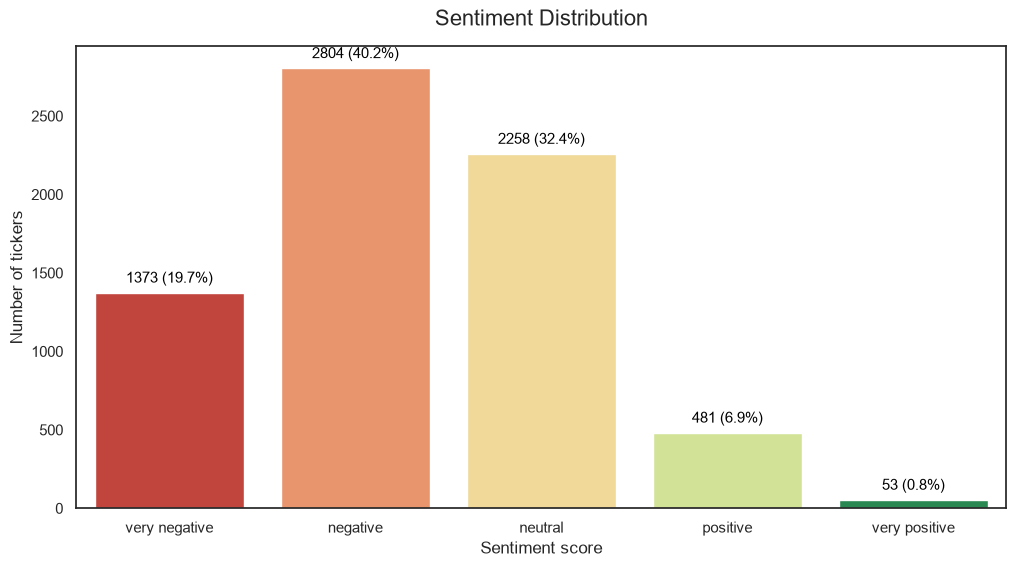

In [ ]:
sentiment_order = ["very negative", "negative", "neutral", "positive", "very positive"]
custom_palette = ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#1a9850"] 

plt.figure(figsize=(12, 6))
sns.set_theme(style="white")  

total = len(df_with_ticker) 

ax = sns.countplot(
    data=df_with_ticker, 
    x="sentiment", 
    order=sentiment_order,
    palette=custom_palette
)

plt.title("Sentiment Distribution", fontsize=16, pad=15)
plt.xlabel("Sentiment score", fontsize=12)
plt.ylabel("Number of tickers", fontsize=12)

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count} ({pct:.1f}%)',  # <-- valor + porcentaje
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

ax.grid(False)  
plt.show()

# Agent Architecture

To automate the execution of our sentiment analysis script (`student_job_LLM.py`) on the Leonardo cluster, we will build an agentic system using **LangChain** (specifically the `create_agent` factory with LangGraph underneath).
The agent will be powered by the **Mistral-Small-3.2-24B-Instruct** model running on the cluster.

## Tools Provided to the Agent
1. **`write_file`**: Allows the agent to create the `.job` (sbatch) file locally. This script will define the SLURM headers (partition, time, nodes) and the command to run the Python pipeline.
2. **`launch_job`**: A Python wrapper around the `sbatch` subprocess command to submit the newly generated `.job` file to the SLURM queue.
3. **`get_running_jobs_for_user`**: A wrapper around the `squeue` subprocess command to monitor the queue.
4. **`get_status_of_a_job`**: A wrapper around the `sacct` command to verify the execution state and exit code.
5. **`read_file`**: Once the job succeeds, the agent will use this to read the output generated by the script and report the findings back to the user.
6. **`list_directory`**: Allows the agent to inspect the contents of the current directory to verify files are present.

## Interaction Flow
1. The User requests: "Run the Reddit sentiment analysis on Leonardo".
2. Agent generates `run_analysis.job` and writes it to disk.
3. Agent runs `launch_job('run_analysis.job')`.
4. Agent polls `squeue` or `sacct` until completion.
5. Agent reads the output file and summarizes the result.

# Agent System Prompt

You are an AI Data Science assistant designed to manage and execute analytical pipelines on the Leonardo SLURM cluster.
You have access to tools that can interact with the file system and the SLURM workload manager.

When instructed to run an analysis, you must follow these exact steps:
1. Create a SLURM batch script using the write_file tool. Ensure you configure the proper #SBATCH directives (e.g. partition, time, nodes) and include the command to execute `python student_job_LLM.py`.
2. Submit the job using the launch_job tool and capture the returned Job ID.
3. Monitor the job status using the get_running_jobs_for_user or get_status_of_a_job tools. Do not submit duplicate jobs while waiting.
4. If a step fails (e.g. invalid partition), read the error, correct your script, and try again.
5. Once the job completes successfully, use the read_file tool to read the output file generated by the job.
6. Provide a concise summary of the results to the user.

Always use relative paths based on the current working directory.
```

In [ ]:
# Agent Implementation
import os
import subprocess
from pathlib import Path
from langchain.agents.factory import create_agent
from langchain_community.tools.file_management import ReadFileTool, WriteFileTool, ListDirectoryTool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents.middleware.todo import TodoListMiddleware
from langchain.agents.middleware import SummarizationMiddleware

# 1. Define SLURM Subprocess Tools
def get_running_jobs_for_user(user: str):
    """Retrieve the list of jobs currently queued or running on the SLURM cluster for a given user."""
    command = ["squeue", "-u", user]
    return subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True).stdout

def get_status_of_a_job(job_id: int):
    """Retrieve detailed status and accounting information for a specific SLURM job."""
    command = ["sacct", "-j", str(job_id), "--format=JobID,JobName,State,ExitCode,Elapsed,CPUTime", "-P"]
    return subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True).stdout

def launch_job(script_path: str):
    """Submit a job script to the SLURM scheduler using sbatch."""
    command = ["sbatch", script_path]
    return subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True).stdout
    
def get_ticker_stats(ticker: str) -> str:
    """
    Useful to get the sentiment analysis statistics for a specific stock ticker.
    Input should be the ticker symbol (e.g., 'AAPL', 'TSLA').
    """
    try:
        # Read the file generate by SLUMR job
        df = pd.read_csv("sentiment_analysis_results.csv")
        
        # Filter ticker the user asks 
        ticker_df = df[df["ticker"].str.upper() == ticker.upper()]
        
        if len(ticker_df) == 0:
            return f"No mentions found for ticker {ticker} in the dataset."
        
        # sentiment frequency 
        stats = ticker_df["sentiment"].value_counts().to_dict()
        return f"Found {len(ticker_df)} mentions for {ticker}. Sentiment breakdown: {stats}"
    except Exception as e:
        return f"Error reading data: {str(e)}"

# 2. Gather Tools
ROOT_DIR = str(Path.cwd().resolve())
agent_tools = [
    ReadFileTool(root_dir=ROOT_DIR),
    WriteFileTool(root_dir=ROOT_DIR),
    ListDirectoryTool(root_dir=ROOT_DIR),
    get_running_jobs_for_user,
    get_status_of_a_job,
    launch_job,
    get_ticker_stats
]

# 3. Create the Agent
checkpointer = MemorySaver()
middlewares = [
    SummarizationMiddleware(llm, trigger=("tokens", 100000), keep=("messages", 20)),
    TodoListMiddleware(),
]

agent = create_agent(
    model=llm, 
    tools=agent_tools,
    checkpointer=checkpointer,
    middleware=middlewares,
)

# 4. Define Execution Wrapper
def invoke_agent(message: str, agent_graph, thread_id: str = "123"):
    config = {"configurable": {"thread_id": thread_id}}
    for state in agent_graph.stream(
        {"messages": [HumanMessage(content=message)]},
        config=config,
        stream_mode="values",
    ):
        last_msg = state["messages"][-1]
        if isinstance(last_msg, AIMessage) and last_msg.content:
            print(f"\n[Agent]: {last_msg.content}")
        for tc in getattr(last_msg, 'tool_calls', []):
            print(f"\n[Tool Call] {tc['name']}: {tc['args']}")
        if isinstance(last_msg, ToolMessage):
            print(f"\n[Tool Result] ({last_msg.name}): {last_msg.content}")


ModuleNotFoundError: No module named 'langchain_community'

In [ ]:
prompt = """
Please create an sbatch script named 'run_analysis.job' that runs 'student_job_LLM.py'. 
Here are the SLURM requirements you asked for:
- Account: tra26_bbs
- Partition: boost_usr_prod
- QOS: normal
- Nodes: 1
- Tasks per node: 1
- CPUs per task: 8
- GPUs: 1 (--gres=gpu:1)
- Time: 01:00:00

Before running the python script, make sure to include this command to activate the environment:
source /leonardo_scratch/fast/tra26_bbs/intro_to_llms_venv/bin/activate

After creating it, submit it, wait for completion, and read the output.
"""
invoke_agent(prompt, agent)

In [ ]:
prompt = "Please check the status of job xxxxxx again. If the state is COMPLETED, read the output file 'student_LLM_job.out' and give me the final summary. If it's still running, let me know."
invoke_agent(prompt, agent)